# Problem Statement

A retail company wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month.
The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.

## Importing Libraries and Loading data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = pd.read_csv("BlackFridaySales.csv")
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


## Dataset Understanding

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [5]:
data.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [6]:
data.shape

(550068, 12)

In [7]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

# Data Cleaning

## Missing Values

In [8]:
data['Product_Category_2'].fillna(0,inplace=True)
data['Product_Category_3'].fillna(0,inplace=True)

C:\Users\baps\AppData\Local\Temp\ipykernel_8204\731683015.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Product_Category_2'].fillna(0,inplace=True)
C:\Users\baps\AppData\Local\Temp\ipykernel_8204\731683015.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

## Remove unnecessary columns

In [9]:
data.drop(['User_ID','Product_ID'],axis=1,inplace=True)

# Exploratory Data Analysis (EDA)

# Gender Distribution

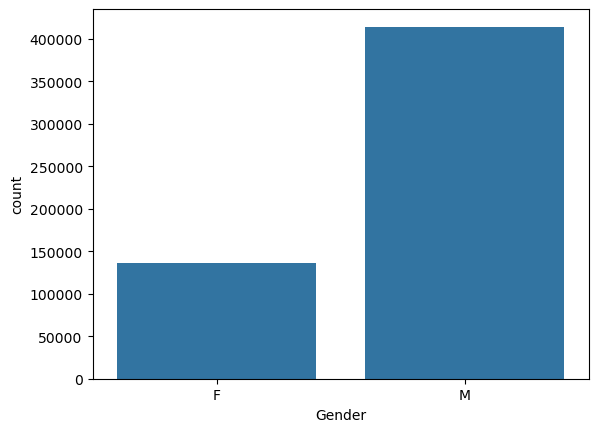

In [10]:
sns.countplot(x='Gender',data=data)
plt.show()

## Age Distribution

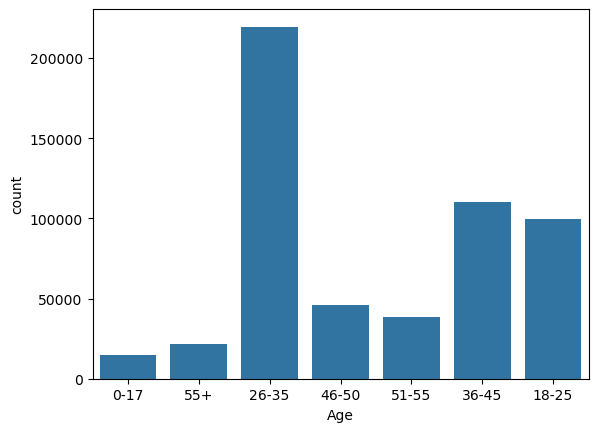

In [11]:
sns.countplot(x='Age',data=data)
plt.show()

## Purchase Distribution

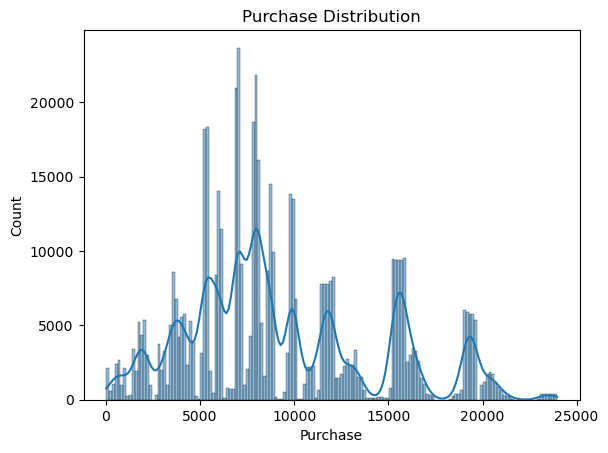

In [12]:
sns.histplot(data['Purchase'], kde=True)
plt.title("Purchase Distribution")
plt.show()

Most customers make purchases in a specific range, while a few customers spend significantly more.

## Gender vs Purchase

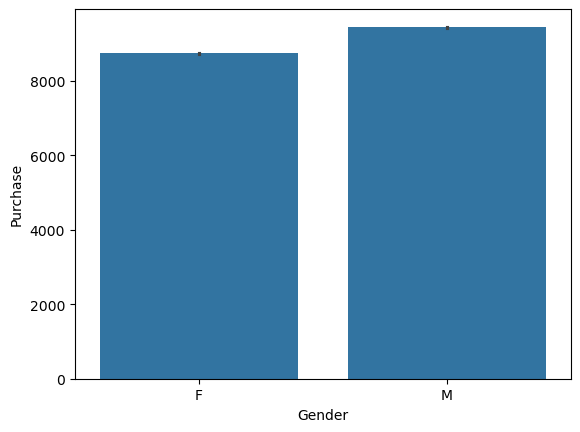

In [13]:
sns.barplot(x='Gender', y='Purchase', data=data)
plt.show()

Male and female customers show different spending patterns, which can help in targeted marketing.

## Age vs Purchase

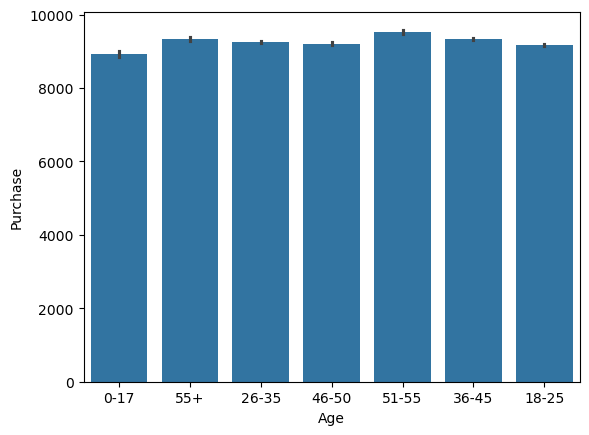

In [14]:
sns.barplot(x='Age', y='Purchase', data=data)
plt.show()

Certain age groups contribute more to overall sales and represent key customer segments.

## City Category vs Purchase

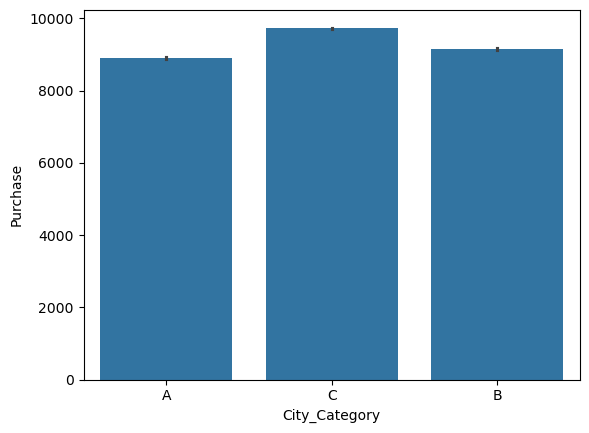

In [15]:
sns.barplot(x='City_Category', y='Purchase', data=data)
plt.show()

## Correlation Heatmap

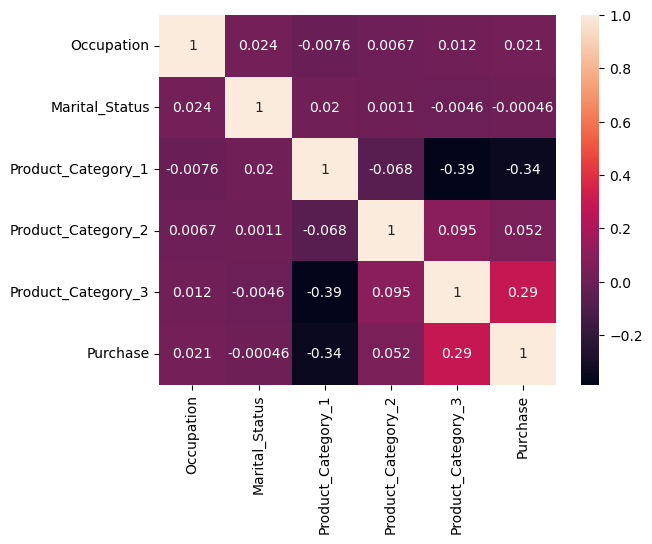

In [16]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

# Data Preprocessing

## Handle Missing Values

In [17]:
data['Product_Category_2'] = data['Product_Category_2'].fillna(0)
data['Product_Category_3'] = data['Product_Category_3'].fillna(0)

## Remove Unnecessary Columns

In [18]:
print(data.columns)

Index(['Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')


In [19]:
data.head()

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,F,0-17,10,A,2,0,3,0.0,0.0,8370
1,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,F,0-17,10,A,2,0,12,0.0,0.0,1422
3,F,0-17,10,A,2,0,12,14.0,0.0,1057
4,M,55+,16,C,4+,0,8,0.0,0.0,7969


# Encoding

In [20]:
data = pd.get_dummies(
    data,
    columns=['Gender','Age','City_Category'],
    drop_first=True
)

In [21]:
data.head()

,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Gender_M,Age_18-25,Age_26-35,Age_36-45,Age_46-50,Age_51-55,Age_55+,City_Category_B,City_Category_C
0,10,2,0,3,0.0,0.0,8370,False,False,False,False,False,False,False,False,False
1,10,2,0,1,6.0,14.0,15200,False,False,False,False,False,False,False,False,False
2,10,2,0,12,0.0,0.0,1422,False,False,False,False,False,False,False,False,False
3,10,2,0,12,14.0,0.0,1057,False,False,False,False,False,False,False,False,False
4,16,4+,0,8,0.0,0.0,7969,True,False,False,False,False,False,True,False,True


In [22]:
data['Stay_In_Current_City_Years'] = data['Stay_In_Current_City_Years'].replace('4+', 4)
data['Stay_In_Current_City_Years'] = data['Stay_In_Current_City_Years'].astype(int)

In [23]:
data.select_dtypes(include='object').columns

Index([], dtype='object')

# Define Features and Target

In [24]:
X = data.drop('Purchase', axis=1)
y = data['Purchase']

# Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Models

## Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

# Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# XGBoost

In [28]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

# Prediction

In [29]:
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)

# Evaluation

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [31]:
mae = mean_absolute_error(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2 = r2_score(y_test, pred_xgb)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 2193.104148705687
RMSE : 2923.114198810593
R2 : 0.6599325230489352


# Model Comparison Table

## Calculate R² for Linear Regression

In [32]:
from sklearn.metrics import r2_score

pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, pred_lr)

print("Linear Regression R2:", lr_r2)

Linear Regression R2: 0.15140056221136122


## Calculate R² for Random Forest

In [33]:
pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, pred_rf)

print("Random Forest R2:", rf_r2)

Random Forest R2: 0.6272586302931832


In [34]:
pred_xgb = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, pred_xgb)

print("XGBoost R2:", xgb_r2)

XGBoost R2: 0.6599325230489352


In [35]:
results = pd.DataFrame({
    'Model':['Linear Regression','Random Forest','XGBoost'],
    'R2 Score':[lr_r2, rf_r2, xgb_r2]
})

results

,Model,R2 Score
0,Linear Regression,0.151401
1,Random Forest,0.627259
2,XGBoost,0.659933


# Feature Importance

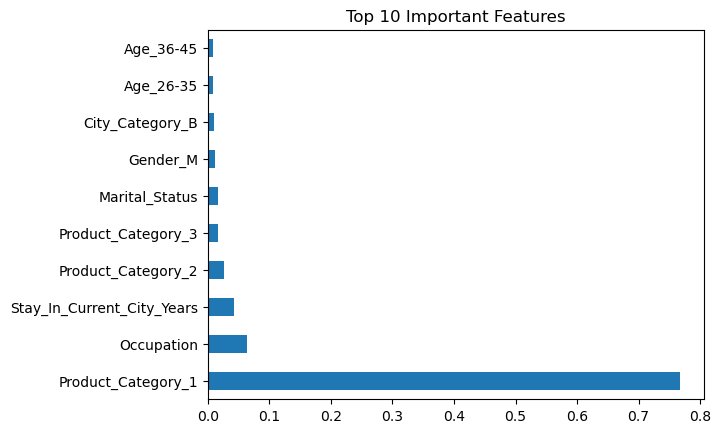

In [36]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [37]:
results.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
2,XGBoost,0.659933
1,Random Forest,0.627259
0,Linear Regression,0.151401


In [38]:
pred_rf = rf.predict(X_test)

print("Actual:", y_test.iloc[0])
print("Predicted:", pred_rf[0])

Actual: 19142
Predicted: 13065.763054729583
